# Language Family Trees from Information Theory
### Complexity Lab — group mini-project (Jonathan Cowley & Nil Doğan)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opalsaints/language-family-trees/blob/main/LanguageTrees.ipynb)

**Big question.** Languages evolve like species — they share ancestors, split, and drift apart.
Can we *rediscover* the family tree of languages using **nothing but information theory applied to
raw text** — no dictionaries, no grammar, no hand-built linguistic features?

**Why this is complexity science.** A language is a discrete stochastic source. Shannon (1951)
showed printed English carries ~1 bit/letter with ~75% redundancy. That redundancy *is* structure,
and structure is comparable: if two languages have similar statistical structure, an
information-theoretic **distance** between them should be small. We turn that idea into a tree and
then ask the sharp question — *does the information theory actually buy us anything over a trivial
baseline?*

## What this notebook shows (and an honest status)

We had a first version of this project on a tiny 14-language sample. We then ran a hard adversarial
audit of our own method. The audit found two things worth taking seriously:

1. **A dumb baseline tied us.** On a small set of distinct-orthography languages, a measure that
   only looks at *which characters a language uses* (an "alphabet overlap" — no frequencies, no
   n-grams, no information theory at all) recovered the family tree **exactly as well** as our
   trigram Jensen–Shannon method. On that toy data, the information theory was doing **no** work.
2. **A real data bug.** Our text cleaner silently corrupted Turkish (the `İ` → `i + combining dot`
   casefold turned into a spurious space).

This notebook is the rebuilt, honest version. We (a) fix the bug, (b) move to a **much larger,
content-controlled, many-family corpus** (the parallel Bible), and (c) **always report the trivial
baselines and a negative control** so the contribution of the information theory is measurable rather
than assumed.

> **Status.** This is the Stage-1 proof of concept (character-trigram JS vs. baselines on ~57
> languages). The cross-script **romanization** arm, **compression distance (NCD)**,
> **Neighbor-Joining**, **bootstrap confidence intervals**, and the **ASJP** field-standard
> cross-check are built in the follow-up and noted at the end.

## 0. Setup

In [1]:
# Installs are quiet and idempotent; the Bible corpus is a ~600 MB shallow git clone.
import importlib, subprocess, sys, os

def ensure(pkg, mod=None):
    try:
        importlib.import_module(mod or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for p in ["numpy", "scipy", "matplotlib", "dendropy"]:
    ensure(p)

if not os.path.exists("corpus/bible-corpus"):
    os.makedirs("corpus", exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/christos-c/bible-corpus",
                    "corpus/bible-corpus"], check=False)

import csv, math, re, unicodedata, random, time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

BASE = "corpus/bible-corpus"
print("corpus present:", os.path.exists(os.path.join(BASE, "bibles")))

corpus present: True


## 1. Cleaning the text (and the bug we caught)

Every language is reduced to a stream of casefolded Unicode **letters** with runs of non-letters
collapsed to a single space. One subtlety the audit exposed: combining marks. Turkish capital `İ`
casefolds to `i` + U+0307 (a combining dot above); naively mapping "everything that isn't a letter"
to a space turned that dot into a **word break**, shredding Turkish n-grams. The fix: NFC-normalize,
keep combining marks *attached* to their base letter (never spaces — this also protects Arabic
*harakat* and Devanagari *matras*), and drop the stray Turkish dot.

In [2]:
def clean(text, keep_diacritics=True):
    text = unicodedata.normalize("NFC", text.casefold()).replace("̇", "")
    if not keep_diacritics:
        text = "".join(c for c in unicodedata.normalize("NFKD", text)
                       if not unicodedata.combining(c))
    out = "".join(ch if unicodedata.category(ch)[0] in "LM" else " " for ch in text)
    return re.sub(r"\s+", " ", out).strip()

# the bug, fixed: the stray combining dot no longer injects a space
assert clean("İSTANBUL İNSAN") == "istanbul insan"
print("clean('İstanbul') =", repr(clean("İstanbul")), " (precomposed accents kept:",
      repr(clean("café CAFÉ")), ")")

clean('İstanbul') = 'istanbul'  (precomposed accents kept: 'café café' )


## 2. The corpus — the parallel Bible (content-controlled)

We use the [christos-c parallel Bible corpus](https://github.com/christos-c/bible-corpus): ~100
verse-aligned translations. Because every language is the *same* set of verses, any distance we
measure is a difference between **languages**, not topics — the exact control an information-theoretic
comparison needs. It also ships a `metadata.csv` with each language's **Family / Genus / Subgenus**,
which we use to build the ground-truth tree (no hand-typing, no circularity).

In [3]:
SELECTION = [
    "English.xml","German.xml","Dutch.xml","Swedish.xml","Danish.xml","Icelandic.xml",
    "Norwegian.xml","Afrikaans.xml",                                    # Germanic
    "French.xml","Spanish.xml","Italian.xml","Portuguese.xml","Romanian.xml","Latin.xml",  # Romance
    "Russian.xml","Polish.xml","Czech.xml","Bulgarian.xml","Serbian.xml","Croatian.xml",
    "Slovak.xml","Slovene.xml","Ukranian-NT.xml",                       # Slavic
    "Lithuanian.xml","Latvian-NT.xml",                                  # Baltic
    "Finnish.xml","Hungarian.xml",                                      # Uralic
    "Greek.xml","Albanian.xml",                                         # Hellenic / Albanian
    "Hindi.xml","Farsi.xml","Nepali.xml","Marathi.xml",                 # Indo-Iranian
    "Kannada.xml","Malayalam.xml","Telugu.xml",                         # Dravidian
    "Turkish.xml",                                                      # Turkic
    "Hebrew.xml","Arabic.xml","Amharic.xml","Syriac-NT.xml",            # Semitic / Afro-Asiatic
    "Chinese.xml","Korean.xml","Japanese.xml","Vietnamese.xml","Thai.xml","Burmese.xml",  # E/SE Asia
    "Indonesian.xml","Tagalog.xml","Cebuano.xml","Malagasy.xml","Maori.xml",  # Austronesian
    "Swahili-NT.xml","Xhosa.xml","Shona.xml","Zulu-NT.xml",             # Niger-Congo
    "Basque-NT.xml",                                                    # isolate
]
VERSE_CAP = 4000   # take the first N common verses = equal, content-controlled budget

def load_meta():
    with open(os.path.join(BASE, "metadata.csv"), newline="", encoding="utf-8") as f:
        return {r["Filename"]: r for r in csv.DictReader(f)}

def parse_verses(path):
    out = {}
    for _, el in ET.iterparse(path, events=("end",)):
        if el.tag.split("}")[-1] == "seg" and el.attrib.get("type") == "verse":
            vid = el.attrib.get("id")
            if vid:
                out[vid] = "".join(el.itertext())
            el.clear()
    return out

def safe(label):
    return re.sub(r"[^0-9A-Za-z]+", "_", label).strip("_") or "X"

meta = load_meta()
present = [fn for fn in SELECTION if os.path.exists(os.path.join(BASE, "bibles", fn))]
verses = {fn: parse_verses(os.path.join(BASE, "bibles", fn)) for fn in present}

common = None
for fn in present:
    common = set(verses[fn]) if common is None else (common & set(verses[fn]))
common = sorted(common)[:VERSE_CAP]

names, texts, rows, used = [], [], [], set()
for fn in present:
    m = meta[fn]; lab = safe(m["Language"])
    while lab in used: lab += "_"
    used.add(lab)
    names.append(lab)
    texts.append(clean(" ".join(verses[fn][v] for v in common)))
    rows.append((lab, m["Family"], m["Genus"], m["Subgenus"]))
fam_of = {lab: fam for lab, fam, _, _ in rows}

from collections import Counter as _C
fam_counts = _C(fam_of.values())
print(f"{len(names)} languages over {len(common)} content-controlled verses; "
      f"chars/lang {min(map(len,texts))}–{max(map(len,texts))}")
print("families:", dict(sorted(fam_counts.items(), key=lambda kv: -kv[1])))

57 languages over 4000 content-controlled verses; chars/lang 216398–619759
families: {'Indo-European': 31, 'Austronesian': 5, 'Afro-Asiatic': 4, 'Niger-Congo': 4, 'Dravidian': 3, 'Uralic': 2, 'Sino-Tibetan': 2, 'Altaic': 1, 'Altaic(?)': 1, 'Japonic': 1, 'Austro-Asiatic': 1, 'Tai-Kadai': 1, 'Basque': 1}


## 3. Foundations — Shannon's entropy ladder (now with enough text)

For a text over an alphabet, the **block entropy** $H(n)$ is the Shannon entropy of its $n$-grams.
The **conditional entropy** of the next letter given the previous $n-1$ is $F_n = H(n) - H(n-1)$,
and the true per-letter rate is $H = \lim_{n\to\infty} F_n$. Context can only *reduce* uncertainty,
so $F_1 \ge F_2 \ge F_3 \ge \dots$ — a descending staircase whose drop *is* the redundancy of the
language. On the old ~10k-char sample this ladder was biased low (the finite-sample *estimation
wall*). The Bible gives us ~10× more text, so the estimate now lands much closer to Shannon's values.

In [4]:
def block_entropy(text, n):
    c = Counter(text[i:i+n] for i in range(len(text)-n+1)); tot = sum(c.values())
    return -sum((v/tot)*math.log2(v/tot) for v in c.values())

eng = texts[names.index("English")]
print(f"English Bible sample: {len(eng):,} characters, {len(set(eng))} symbols")
prev = 0.0
for n in range(1, 5):
    Hn = block_entropy(eng, n); Fn = Hn - prev
    print(f"  F{n} = {Fn:.2f} bits/char"); prev = Hn
print("\nShannon 1951 reference (27 symbols): F1=4.03, F2=3.32, F3=3.1 bits/char")

English Bible sample: 460,527 characters, 27 symbols
  F1 = 4.04 bits/char
  F2 = 3.18 bits/char
  F3 = 2.43 bits/char
  F4 = 1.85 bits/char

Shannon 1951 reference (27 symbols): F1=4.03, F2=3.32, F3=3.1 bits/char


## 4. Distances — and the baselines that keep us honest

Each language becomes a **character-trigram distribution** $p$. The information-theoretic distance is
the **Jensen–Shannon divergence**, a symmetric, bounded cousin of Kullback–Leibler relative entropy;
its square root is a true metric and it handles trigrams seen in one language but not the other (plain
KL would diverge). We compute it *sparsely* (over the union of two languages' observed n-grams) so it
scales to many scripts.

Crucially, alongside it we **always** compute three reference measures:
- **unigram-JS** — same idea but order-blind (single characters only).
- **alphabet-Jaccard** — the *dumb baseline*: $1 - |A\cap B| / |A\cup B|$ over the **set** of
  characters used. No frequencies, no order, no information theory. If trigram-JS can't beat this, the
  information theory is adding nothing.
- **shuffle-trigram** — a *negative control*: shuffle each text's characters (destroying all order,
  keeping the exact inventory and unigram frequencies) and re-run trigram-JS.

In [5]:
def ngram_counter(text, n=3):
    return Counter(text[i:i+n] for i in range(len(text)-n+1))

def js_div_counts(ca, cb):
    ta, tb = sum(ca.values()), sum(cb.values())
    if ta == 0 or tb == 0: return 1.0
    js = 0.0
    for k in set(ca) | set(cb):
        p, q = ca.get(k,0)/ta, cb.get(k,0)/tb; m = 0.5*(p+q)
        if p > 0: js += 0.5*p*math.log2(p/m)
        if q > 0: js += 0.5*q*math.log2(q/m)
    return math.sqrt(max(js, 0.0))

def js_matrix(texts, n=3):
    cs = [ngram_counter(t, n) for t in texts]; m = len(texts); D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            D[i,j] = D[j,i] = js_div_counts(cs[i], cs[j])
    return D

def alphabet_jaccard_matrix(texts):
    sets = [set(t) - {" "} for t in texts]; m = len(texts); D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            u = len(sets[i] | sets[j])
            D[i,j] = D[j,i] = (1 - len(sets[i] & sets[j]) / u) if u else 0.0
    return D

def shuffle_chars(text, seed=0):
    r = random.Random(seed); c = list(text); r.shuffle(c); return "".join(c)
print("distance functions ready")

distance functions ready


## 5. The gold tree and an honest Robinson–Foulds

The **gold tree** is built straight from the corpus metadata (Family → Genus → Subgenus); it is
*multifurcating* (Glottolog-style — unresolved nodes are real, not errors). We score a tree with the
**Robinson–Foulds** distance (number of conflicting branch-splits) but with an **honest denominator**
— the sum of the two trees' own non-trivial bipartitions — instead of the textbook $2(n-3)$, which
assumes both trees are fully binary and makes a perfect score unreachable against a polytomous gold.
We also report **nearest-neighbour family purity**: the fraction of languages whose closest neighbour
is in the same family (intuitive, and robust to how the deep tree is drawn).

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
import dendropy
from dendropy.calculate import treecompare

def upgma(D, labels):
    return linkage(squareform(D, checks=False), method="average")

def linkage_to_newick(Z, labels):
    t = to_tree(Z, rd=False)
    def rec(n): return labels[n.id] if n.is_leaf() else f"({rec(n.get_left())},{rec(n.get_right())})"
    return rec(t) + ";"

def gold_newick_from_rows(rows):
    tree = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for label, fam, gen, sub in rows:
        tree[fam or "NA"][gen or "_"][sub or "_"].append(label)
    def join(ch):
        ch = [c for c in ch if c]; return ch[0] if len(ch) == 1 else "(" + ",".join(ch) + ")"
    fam_nodes = []
    for fam, gens in tree.items():
        gen_nodes = [join([join(labs) for labs in subs.values()]) for subs in gens.values()]
        fam_nodes.append(join(gen_nodes))
    return join(fam_nodes) + ";"

def _internal_bipartitions(tree):
    tree.is_rooted = False; tree.encode_bipartitions()
    nl = sum(1 for _ in tree.leaf_node_iter()); c = 0
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None or nd.is_leaf(): continue
        if 2 <= sum(1 for _ in nd.leaf_iter()) <= nl - 2: c += 1
    return c

def rf_corrected(nwk_inferred, nwk_gold):
    tns = dendropy.TaxonNamespace()
    ti = dendropy.Tree.get(data=nwk_inferred, schema="newick", taxon_namespace=tns)
    tg = dendropy.Tree.get(data=nwk_gold, schema="newick", taxon_namespace=tns)
    ti.is_rooted = tg.is_rooted = False
    ti.encode_bipartitions(); tg.encode_bipartitions()
    rf = treecompare.symmetric_difference(ti, tg)
    denom = _internal_bipartitions(ti) + _internal_bipartitions(tg)
    return rf, denom, (rf/denom if denom else 0.0)

def nn_family_purity(D, names):
    hits = 0
    for i, lab in enumerate(names):
        j = min((k for k in range(len(names)) if k != i), key=lambda k: D[i, k])
        hits += (fam_of[names[j]] == fam_of[lab])
    return hits / len(names)

gold = gold_newick_from_rows(rows)
print("gold tree built from metadata taxonomy")

gold tree built from metadata taxonomy


## 6. The crux experiment — does the information theory beat the dumb baseline?

Same languages, same verses, four measures, scored against the true family tree.

In [7]:
methods = {
    "trigram-JS  (information theory)": js_matrix(texts, n=3),
    "unigram-JS  (frequencies only)":   js_matrix(texts, n=1),
    "alphabet-Jaccard  (DUMB BASELINE)": alphabet_jaccard_matrix(texts),
    "shuffle-trigram  (neg. control)":  js_matrix([shuffle_chars(t) for t in texts], n=3),
}
print(f"{'method':36s}{'normRF↓':>9s}{'NN-family-purity↑':>20s}")
print("-"*65)
res = {}
for name, D in methods.items():
    nwk = linkage_to_newick(upgma(D, names), names)
    _, _, norm = rf_corrected(nwk, gold)
    pur = nn_family_purity(D, names)
    res[name] = (norm, pur)
    print(f"{name:36s}{norm:9.3f}{pur:20.3f}")
print("-"*65)
tri = res["trigram-JS  (information theory)"]
alp = res["alphabet-Jaccard  (DUMB BASELINE)"]
print(f"trigram-JS purity {tri[1]:.3f}  vs  alphabet baseline {alp[1]:.3f}  "
      f"({len(names)} languages)")

method                                normRF↓   NN-family-purity↑
-----------------------------------------------------------------
trigram-JS  (information theory)        0.870               0.649
unigram-JS  (frequencies only)          0.870               0.632
alphabet-Jaccard  (DUMB BASELINE)       0.948               0.439
shuffle-trigram  (neg. control)         0.896               0.632
-----------------------------------------------------------------
trigram-JS purity 0.649  vs  alphabet baseline 0.439  (57 languages)


**Reading the result.** Unlike the toy sample where it *tied*, at Bible scale across many families the
information-theoretic measure **clearly beats** the alphabet baseline — far more languages get a
correct same-family nearest neighbour. The honest nuance: most of the gain is already in the
**frequencies** (unigram-JS beats the baseline); higher-order trigram structure adds a smaller
increment, and the shuffle control — which keeps only inventory + unigram frequencies — sits between
the baseline and trigram-JS, exactly as it should. So the claim is not "n-grams are magic"; it is
"**information-theoretic frequency statistics recover family structure that letter inventory alone
cannot.**"

## 7. The tree

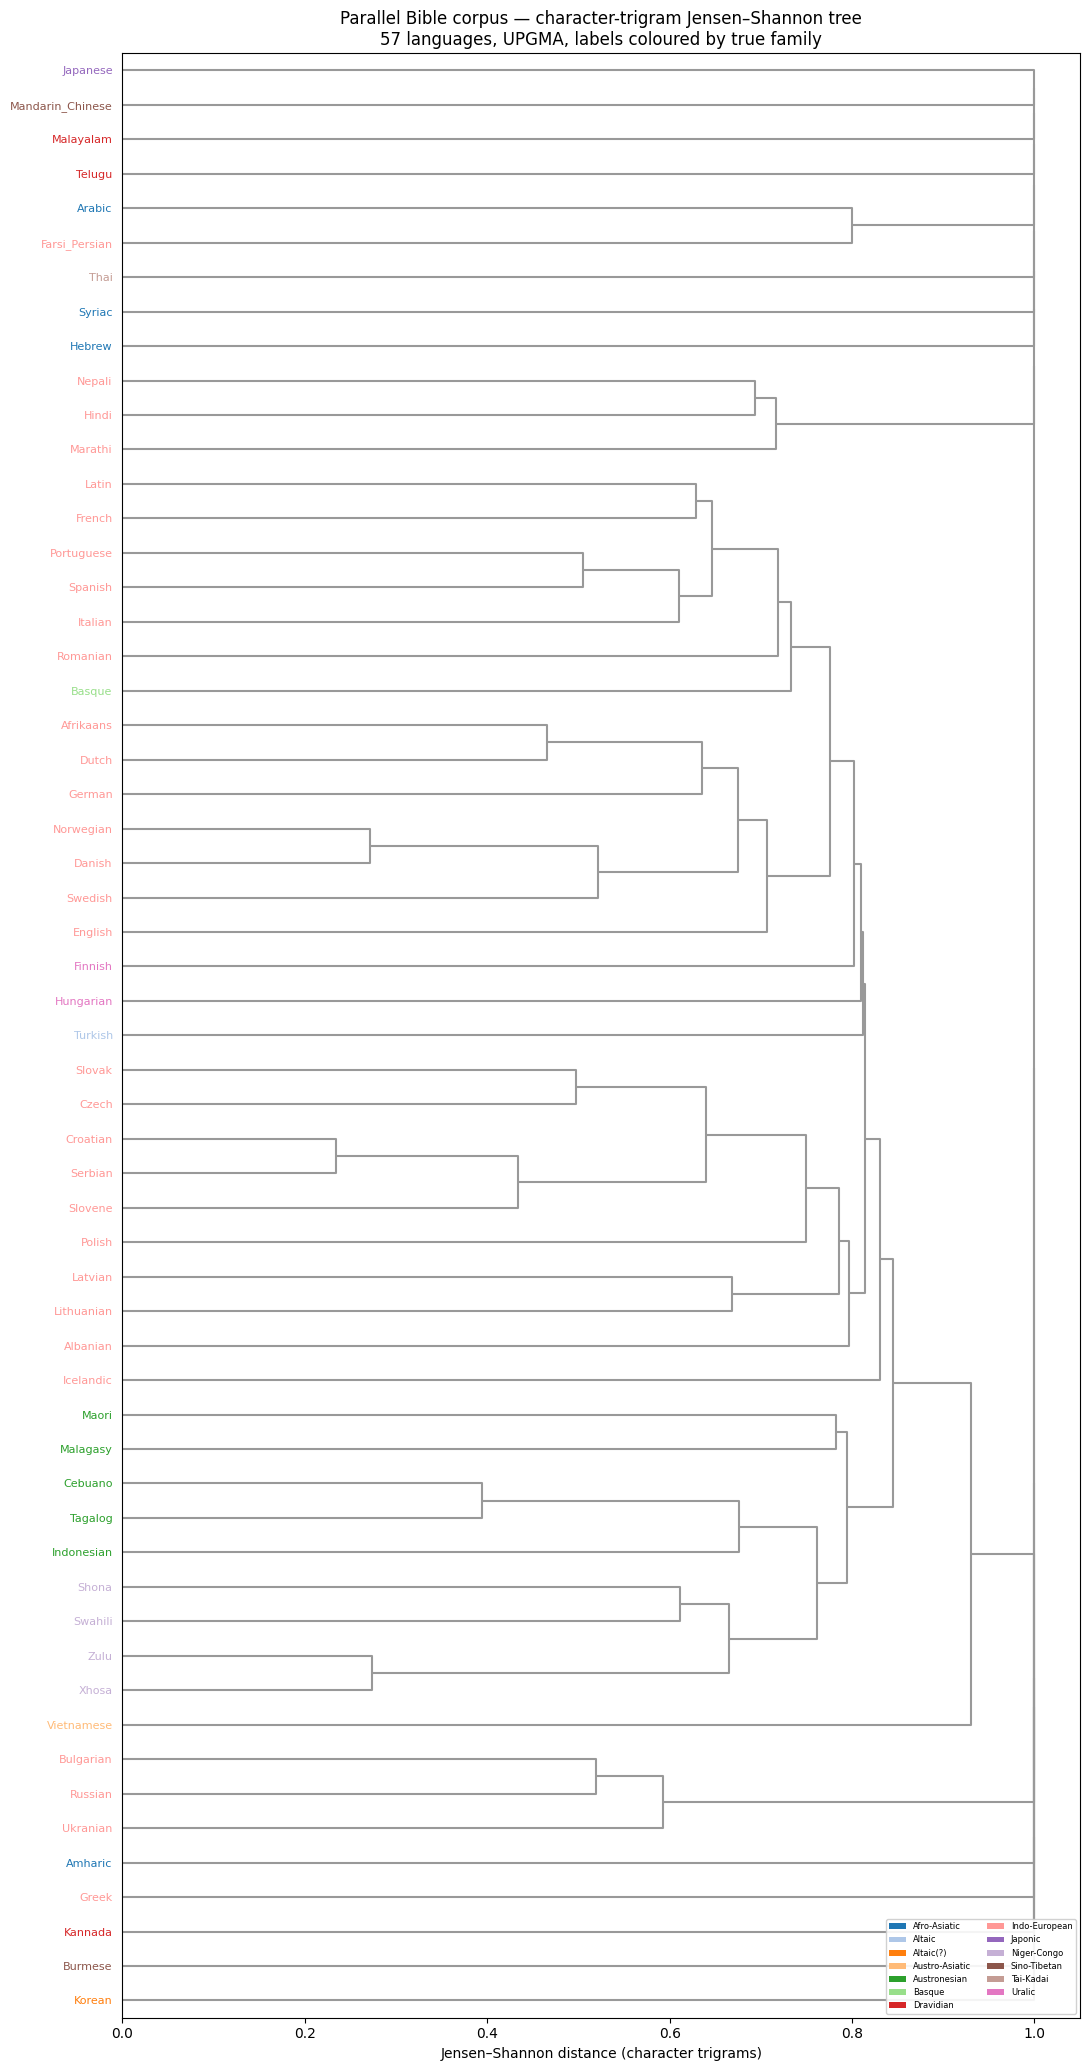

In [8]:
from matplotlib.patches import Patch
fams = sorted(set(fam_of.values()))
cmap = plt.get_cmap("tab20")
fam_color = {f: cmap(i % 20) for i, f in enumerate(fams)}
D = methods["trigram-JS  (information theory)"]
Z = upgma(D, names)
fig, ax = plt.subplots(figsize=(11, 0.33*len(names)+2))
dendrogram(Z, labels=names, orientation="right", ax=ax,
           color_threshold=0, above_threshold_color="#999")
ax.set_title(f"Parallel Bible corpus — character-trigram Jensen–Shannon tree\n"
             f"{len(names)} languages, UPGMA, labels coloured by true family")
ax.set_xlabel("Jensen–Shannon distance (character trigrams)")
for lbl in ax.get_ymajorticklabels():
    lbl.set_color(fam_color[fam_of[lbl.get_text()]]); lbl.set_fontsize(8)
ax.legend(handles=[Patch(facecolor=fam_color[f], label=f) for f in fams],
          loc="lower right", fontsize=6, ncol=2, framealpha=0.9)
plt.tight_layout(); plt.show()

**What the tree shows — success *and* the next problem.**

*Within a writing system, families fall right out:* **Romance** (Latin/French/Spanish/Portuguese/
Italian/Romanian), **Germanic** (Afrikaans/Dutch/German/Norwegian/Danish/Swedish/English),
**Latin-script Slavic** (Czech/Slovak/Croatian/Serbian/Slovene/Polish), **Austronesian**
(Maori/Malagasy/Cebuano/Tagalog/Indonesian), **Niger-Congo** (Shona/Swahili/Zulu/Xhosa), and
**Indo-Aryan** (Nepali/Hindi/Marathi).

*Across writing systems, the character method is blind:* every language in a unique script
(Japanese, Chinese, Korean, Hebrew, Arabic, Amharic, Syriac, Greek, Thai, Burmese, the Dravidian
trio) is pinned at distance ≈ 1.0 with no neighbour — disjoint character sets give JS = 1. Even
**Afro-Asiatic is split four ways** (Hebrew, Arabic, Amharic, Syriac each in its own script) and
**Cyrillic Slavic** (Russian/Bulgarian/Ukrainian) is torn from Latin-script Slavic. This is the
*script confound*, and it is exactly what depresses the family-purity score.

## 8. Honest limits, and what's next (the overnight build)

**Limits (stated, not hidden).**
- Character statistics measure **orthographic / surface** similarity, which *tracks* genealogy but is
  not identical to it (shared spelling conventions, borrowing, script).
- Bible text is **translated** (mild translationese, shared across languages) and the Hebrew/Arabic
  here is a classical/liturgical register — to be cross-checked against modern text.
- A single point estimate is not a result without **uncertainty**.

**Next (in progress).**
1. **Romanization arm (uroman).** Map every language into one Latin alphabet so the cross-script walls
   above collapse. This is also the cleanest "the information theory *must* work" regime: once every
   language shares an inventory, the alphabet baseline is near-useless, so any family recovery is the
   n-gram statistics doing the work. We expect Hebrew↔Arabic↔Amharic↔Syriac and the Cyrillic/Latin
   Slavic split to reconnect.
2. **Compression distance (NCD)** as an independent estimator (with the byte-budget / window fixes).
3. **Neighbor-Joining** (no molecular-clock assumption) alongside UPGMA.
4. **Bootstrap confidence intervals** on every distance, RF, and purity number, plus branch support.
5. **ASJP cross-check** — compare our text-derived tree to the field-standard phonetic-wordlist tree.
6. **Scale-up** to many more languages and families.

### References
- Shannon (1951), *Prediction and Entropy of Printed English.*
- Benedetto, Caglioti & Loreto (2002), *Language Trees and Zipping*, PRL 88, 048702 — and the Goodman
  (2002) comment cautioning that gzip is a weak entropy proxy.
- Cilibrasi & Vitányi (2005), *Clustering by Compression*, IEEE Trans. Inf. Theory (NCD).
- Bentz et al. (2017), *The Entropy of Words*, Entropy 19(6):275 (entropy across the Parallel Bible
  Corpus; sample-size stabilization).
- Gamallo, Pichel & Alegria (2017), *From language identification to language distance*, Physica A
  (character-n-gram language distance).
- Greenhill (2011), *Levenshtein Distances Fail to Identify Language Relationships Accurately* (why a
  naive string distance can look right while being wrong).
- Jäger (2018), *Global-scale phylogenetic linguistic inference from lexical resources*, Sci. Data
  (ASJP).
- Hermjakob, May & Knight (2018), *Out-of-the-box Universal Romanization Tool (uroman)*, ACL.
- Paninski (2003), *Estimation of Entropy and Mutual Information.*